# Built an AI-powered credit risk Assessment

In [ ]:
!pip install google-generativeai
!pip install shap
!pip install faiss-cpu          # For RAG vector search
!pip install sentence-transformers  # For converting text to vectors
!pip install gradio             # For web UI (easier than Streamlit in Colab)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 55.1 MB/s eta 0:00:00


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import shap
import pickle
import os
import faiss
from sentence_transformers import SentenceTransformer
import google.generativeai as genai
%matplotlib inline
plt.style.use('fivethirtyeight')

In [ ]:
df=pd.read_csv("/Credit Risk & Loan Default Prediction.csv")

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
df.shape

(32581, 12)

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
df = df.dropna() ## Handle Missing Values

Encode categorical Columns

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

Define Features and Target
(Replace Loan_Default with actual target column name if different)

In [ ]:
x=df.drop('loan_status',axis=1)
y=df['loan_status']

In [ ]:
## Train Test Split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
    )

In [ ]:
model=RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred=model.predict(x_test)

print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[4423   20]
 [ 373  912]]
0.9313896648044693


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[4423,   20],
       [ 373,  912]])

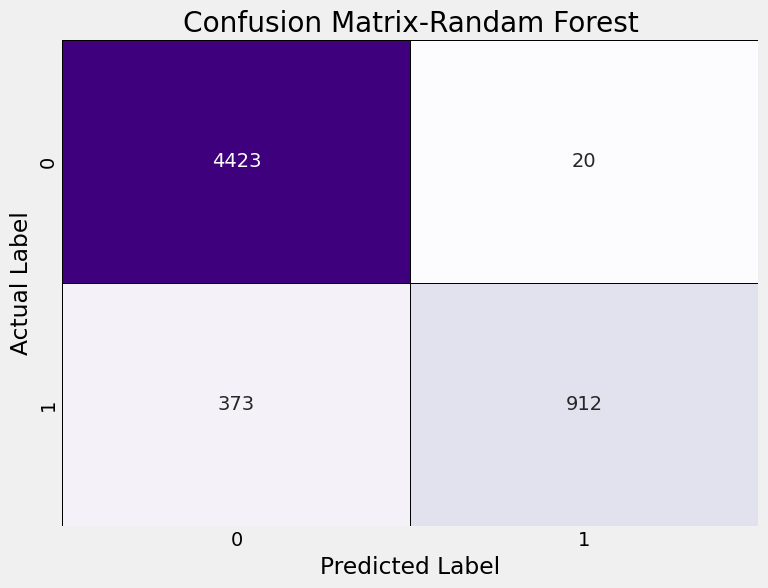

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, linewidths=0.5, linecolor= 'black')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title("Confusion Matrix-Randam Forest")
plt.show()

The confusion matrix shows how well the Random Forest model distinguishes between default and non-default customers. True Positives represent correctly predicted defaults, while False Positives indicate customers wrongly classified as risky.

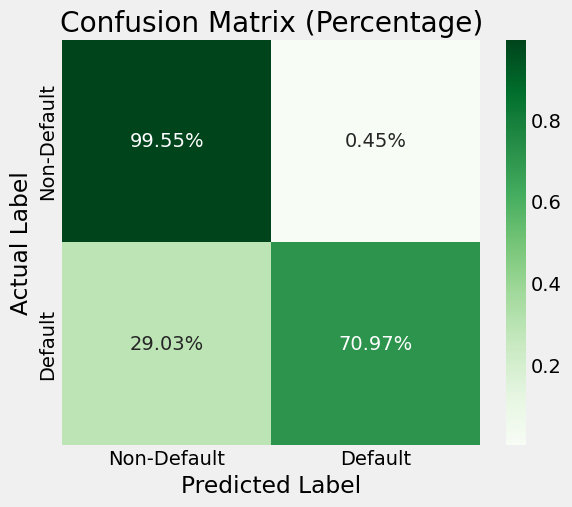

In [ ]:
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))

sns.heatmap(cm_percentage,
            annot=True,
            fmt='.2%',
            cmap='Greens',
            xticklabels=["Non-Default", "Default"],
            yticklabels=["Non-Default", "Default"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()

In [ ]:
y_prob = model.predict_proba(x_test)[:,1]

In [ ]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)

In [ ]:
auc_score= roc_auc_score(y_test,y_prob)
print("AUC SCORE:",auc_score)

AUC SCORE: 0.9323599138591638


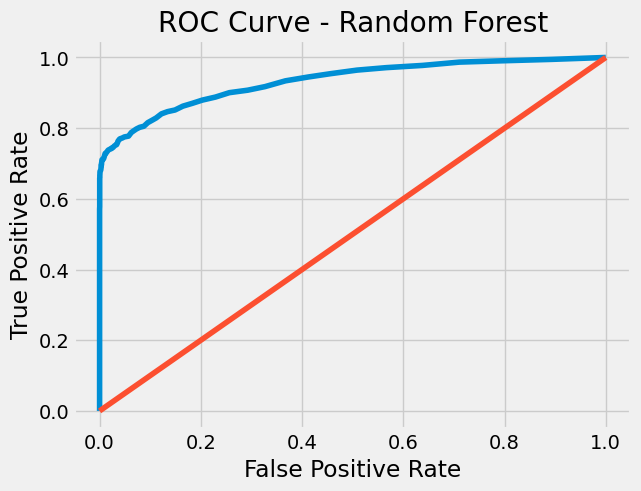

In [ ]:
plt.figure()
plt.plot(fpr,tpr)
plt.plot([0,1], [0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve - Random Forest")
plt.show()

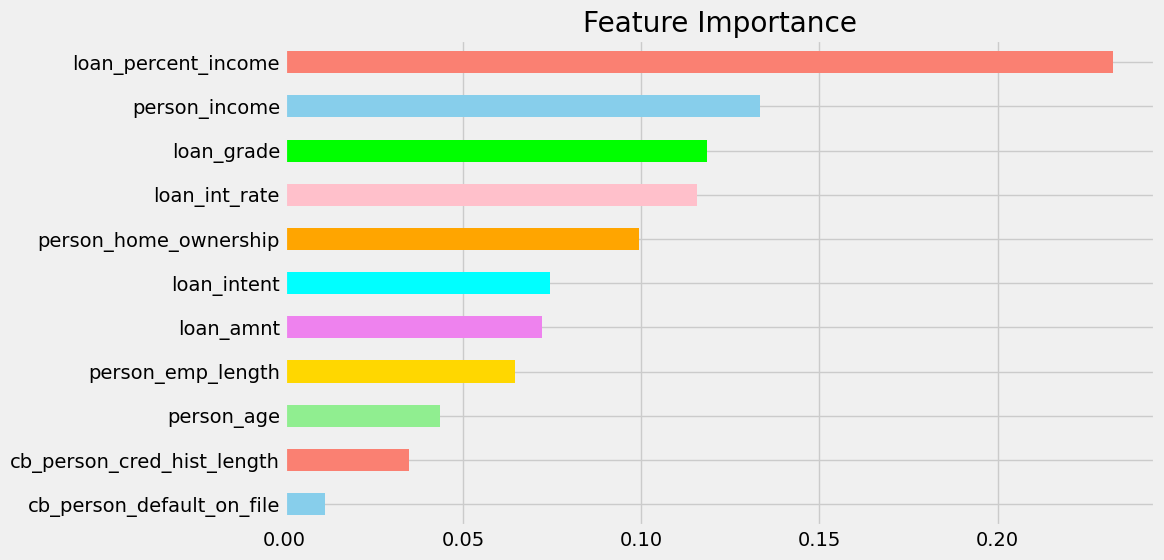

In [ ]:
importances = pd.Series(model.feature_importances_, index=x.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color = ['skyblue', 'salmon', 'lightgreen', 'gold', 'violet', 'cyan', 'orange', 'pink', 'lime'])
plt.title("Feature Importance")
plt.show()

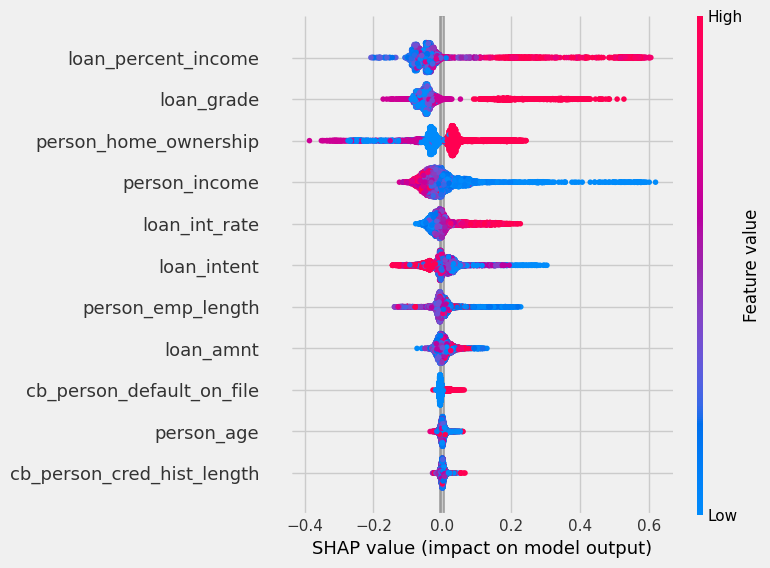

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

# Correctly slice the 3D shap_values array to get SHAP values for class 1 (index 1)
# across all samples and features, assuming shap_values is (n_samples, n_features, n_classes).
# Passing x_test (DataFrame) directly instead of x_test.values (NumPy array) resolves the AssertionError.
shap.summary_plot(shap_values[:, :, 1], x_test, feature_names=x_test.columns)

SHAP helps interpret the Random Forest model by quantifying each feature’s contribution to the prediction. This ensures transparency in credit risk decision-making.”

## GANAI PART (Gemeni Integration)

In [ ]:
import google.generativeai as genai
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

model_gemini = genai.GenerativeModel("gemini-flash-latest")
print("✅ Gemini configured successfully!")

✅ Gemini configured successfully!


In [ ]:
sample = x_test.iloc[0:1]
prediction = model.predict(sample)[0]

prediction

np.int64(0)

In [ ]:
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025


In [ ]:
customer_data = sample.to_dict(orient="records")[0]

prompt = f"""
You are a financial risk analyst AI.

Customer Data:
{customer_data}

Model Prediction:
{prediction} (1 = Default Risk, 0 = Safe)

Explain:
1. Why this customer is risky or safe.
2. What factors contribute most.
3. Recommendation for loan approval.
4. Suggestions to reduce risk.
"""

response = model_gemini.generate_content(prompt)

print(response.text)

As a Financial Risk Analyst AI, I have evaluated the provided data and the model's prediction. Here is the risk assessment report for this applicant.

### 1. Why this customer is considered "Safe"
The model predicts a **0 (Safe)** rating because the applicant exhibits high financial stability relative to the credit they are requesting. At age 27, the applicant has a mature credit history (9 years) relative to their age, suggesting they began managing credit as soon as they were eligible. Their income-to-loan ratio is exceptionally healthy, and their "Loan Grade 0" (typically representing an 'A' grade) indicates they meet the highest standards of creditworthiness.

### 2. Key Contributing Factors
Several factors strongly drive this safe classification:
*   **Low Loan-to-Income Ratio (0.08):** The applicant is only asking for 8% of their annual income ($6,000 loan vs. $75,400 income). This is well below the common risk threshold of 20–30%, suggesting they can easily absorb the monthly pa

I built a hybrid AI system that predicts loan default using Random Forest and enhances decision-making using Gemini LLM for human-readable risk explanations and recommendations.

In [ ]:
user_income = float(input("Enter Income: "))
user_loan = float(input("Enter Loan Amount: "))
user_credit = float(input("Enter Credit Score (e.g., credit history length): "))

# Get the feature names from the training data
feature_names = x_test.columns

# Create a dictionary for the new customer's features
new_customer_data = {}
for col in feature_names:
    if col == 'person_income':
        new_customer_data[col] = user_income
    elif col == 'loan_amnt':
        new_customer_data[col] = user_loan
    elif col == 'cb_person_cred_hist_length': # Using user_credit as proxy for credit history length
        new_customer_data[col] = user_credit
    else:
        # Use the mean value from the training data for other features
        # This is a simplification; for a robust system, more sophisticated imputation would be used.
        new_customer_data[col] = x[col].mean()

# Convert the dictionary to a DataFrame, ensuring correct column order
new_customer = pd.DataFrame([new_customer_data], columns=feature_names)

prediction = model.predict(new_customer)[0]

prompt = f"""
Customer details:
Income (person_income): {user_income}
Loan Amount (loan_amnt): {user_loan}
Credit Score (cb_person_cred_hist_length): {user_credit}

Model Prediction: {prediction} (1 = Default Risk, 0 = Safe)

Explain risk and recommendation.
"""

response = model_gemini.generate_content(prompt)
print(response.text)

Enter Income: 32500
Enter Loan Amount: 1500
Enter Credit Score (e.g., credit history length): 2
Based on the data provided and the model’s prediction, here is an explanation of the risk assessment and the resulting recommendation.

### **Risk Analysis**

**1. Debt-to-Income Ratio (Very Low Risk)**
*   The customer is requesting a loan of **$1,500** against an annual income of **$32,500**.
*   The loan amount represents only **4.6%** of their annual income. This suggests that the monthly payments will be very manageable, leaving the customer with plenty of disposable income to cover other expenses.

**2. Credit History Length (Moderate Risk)**
*   The credit history length is **2 years**. 
*   In the lending world, this is considered a "thin" credit file. While not negative, it provides limited data on how the customer handles debt over long periods or during economic fluctuations. However, for a small loan amount ($1,500), this is generally acceptable.

**3. Model Prediction (Safe)**
*

I developed an AI-powered loan risk chatbot that integrates a Random Forest model for prediction and Gemini LLM for generating human-readable financial risk explanations.

## RAG


In [ ]:
loan_knowledge_base = [
    """LOAN POLICY - CREDIT SCORE GUIDELINES:
    Customers with credit history less than 2 years are considered high risk.
    Customers with credit history 2-5 years are medium risk.
    Customers with credit history above 5 years are low risk.
    Credit score below 580 means very high default probability.""",

    """LOAN POLICY - INCOME TO LOAN RATIO:
    Safe loan: Loan amount should not exceed 3x annual income.
    Moderate risk: Loan amount between 3x-5x annual income.
    High risk: Loan amount exceeding 5x annual income.
    Debt-to-income ratio above 43% is a red flag for default.""",

    """LOAN POLICY - LOAN INTENT GUIDELINES:
    Education loans have lower default rates (8%).
    Medical emergency loans have moderate default rates (12%).
    Personal/consolidation loans have higher default rates (18%).
    Business loans depend heavily on business type and income stability.""",

    """RISK MITIGATION STRATEGIES:
    Recommendation 1: Request a co-signer for high-risk applicants.
    Recommendation 2: Offer smaller loan with option to increase after 6 months.
    Recommendation 3: Higher interest rate for medium-risk customers.
    Recommendation 4: Financial counseling required for debt-to-income > 40%.
    Recommendation 5: Collateral required for loans above $20,000 for risky customers.""",

    """REGULATORY GUIDELINES:
    All loan decisions must comply with Equal Credit Opportunity Act (ECOA).
    Fair Credit Reporting Act (FCRA) requires accurate credit reporting.
    Customers must be informed of denial reasons within 30 days.
    AI-based decisions must be explainable and auditable.""",
]

In [ ]:
print(f"Knowledge base created with {len(loan_knowledge_base)} documents")
print("Documents cover: Credit Score, Income Ratio, Loan Intent, Risk Mitigation, Regulations")

Knowledge base created with 5 documents
Documents cover: Credit Score, Income Ratio, Loan Intent, Risk Mitigation, Regulations


##  CREATE EMBEDDINGS FOR VECTOR SEARCH

In [ ]:
print("Loading embedding model... (first time takes ~1 min)")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Embedding model loaded!")

Loading embedding model... (first time takes ~1 min)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded!


In [ ]:
doc_embeddings = embedding_model.encode(loan_knowledge_base, convert_to_numpy=True)
print(f"✅ Created embeddings: shape = {doc_embeddings.shape}")

✅ Created embeddings: shape = (5, 384)


In [ ]:
# Build FAISS index (this is the "search engine" for your documents)
dimension = doc_embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)  # L2 = Euclidean distance search
faiss_index.add(doc_embeddings)
print(f"FAISS index built with {faiss_index.ntotal} documents")
print("RAG search engine is ready!")

FAISS index built with 5 documents
RAG search engine is ready!


## RAG - RETRIEVAL FUNCTION

In [ ]:
def retrieve_relevant_context(query, top_k=2):
    """
    Given a question, find the most relevant documents from knowledge base.

    Args:
        query: The user's question or customer situation
        top_k: How many documents to retrieve (default 2)

    Returns:
        String with the most relevant context
    """
    # Convert query to vector
    query_vector = embedding_model.encode([query], convert_to_numpy=True)

    # Search FAISS index for most similar documents
    distances, indices = faiss_index.search(query_vector, top_k)

    # Collect the relevant documents
    retrieved_docs = []
    for idx in indices[0]:
        if idx < len(loan_knowledge_base):
            retrieved_docs.append(loan_knowledge_base[idx])

    # Combine into one context string
    context = "\n\n---\n\n".join(retrieved_docs)
    return context


In [ ]:
 # TEST the retrieval function
test_query = "What should I do for a customer with low income and high loan amount?"
context = retrieve_relevant_context(test_query)
print("🔍 Test Query:", test_query)
print("\n📄 Retrieved Context:")
print(context[:500] + "...")

🔍 Test Query: What should I do for a customer with low income and high loan amount?

📄 Retrieved Context:
RISK MITIGATION STRATEGIES:
    Recommendation 1: Request a co-signer for high-risk applicants.
    Recommendation 2: Offer smaller loan with option to increase after 6 months.
    Recommendation 3: Higher interest rate for medium-risk customers.
    Recommendation 4: Financial counseling required for debt-to-income > 40%.
    Recommendation 5: Collateral required for loans above $20,000 for risky customers.

---

LOAN POLICY - INCOME TO LOAN RATIO:
    Safe loan: Loan amount should not exceed 3...


RAG-Powered Gemini Function

In [ ]:
def rag_loan_analysis(customer_data_dict, prediction, shap_top_features=None):
    """
    Full RAG pipeline:
    1. Build query from customer data
    2. Retrieve relevant policy documents
    3. Send everything to Gemini for analysis

    Args:
        customer_data_dict: Dictionary of customer features
        prediction: 0 or 1 from Random Forest
        shap_top_features: Optional - top SHAP features for this customer

    Returns:
        Gemini's analysis string
    """
    risk_label = "HIGH RISK - Likely to Default" if prediction == 1 else "LOW RISK - Safe to Approve"

    # Step 1: Create a search query based on customer situation
    query = f"loan risk analysis income {customer_data_dict.get('person_income', 'unknown')} loan amount {customer_data_dict.get('loan_amnt', 'unknown')} credit history"

    # Step 2: Retrieve relevant policy context (RAG!)
    relevant_context = retrieve_relevant_context(query, top_k=2)

    # Step 3: Build the full prompt with context
    prompt = f"""
You are an expert financial risk analyst AI. Use the POLICY GUIDELINES below to make your analysis.

=== RETRIEVED POLICY GUIDELINES (from knowledge base) ===
{relevant_context}

=== CUSTOMER DATA ===
{customer_data_dict}

=== ML MODEL PREDICTION ===
{prediction} → {risk_label}

=== YOUR TASK ===
Based on the policy guidelines above AND the customer data:
1.  Risk Assessment: Explain why this customer is {risk_label}
2.  Key Factors: What are the top 2-3 factors driving this decision?
3.  Recommendation: Should the loan be approved, denied, or approved with conditions?
4.  Action Plan: Give 2-3 specific steps to reduce risk (cite the policy guidelines)
5.  Compliance Note: Any regulatory considerations?

Be specific, cite the guidelines, and keep it professional.
"""

    # Step 4: Call Gemini
    response = model_gemini.generate_content(prompt)
    return response.text


# TEST with a sample customer
sample_customer = x_test.iloc[0:1]
sample_prediction = model.predict(sample_customer)[0]
sample_dict = sample_customer.to_dict(orient="records")[0]

print("Running RAG-powered analysis...\n")
result = rag_loan_analysis(sample_dict, sample_prediction)
print(result)

Running RAG-powered analysis...

**Financial Risk Analysis Report**

**To:** Loan Underwriting Department
**From:** Senior Risk Analyst AI
**Date:** October 26, 2023
**Subject:** Risk Assessment – Loan Application [Customer Data Ref: 27-75400]

---

### 1. Risk Assessment: LOW RISK - Safe to Approve
The customer presents a high degree of financial stability and a strong credit profile. According to the **LOAN POLICY - INCOME TO LOAN RATIO**, a "Safe loan" is defined as a loan amount not exceeding 3x the annual income. This customer’s annual income is $75,400, meaning a safe loan threshold is up to $226,200. The requested loan of **$6,000** is significantly below this threshold (representing only 0.08 of annual income). 

Furthermore, the customer adheres to the **LOAN POLICY - CREDIT SCORE GUIDELINES** for low-risk profiles, as their credit history length is 9 years, well above the 5-year requirement for the "low risk" designation.

### 2. Key Factors
*   **Superior Income-to-Loan Prof

Multi-turn RAG Chatbot


In [ ]:
def run_rag_chatbot():
    """
    Interactive multi-turn chatbot with:
    - ML prediction
    - RAG context retrieval
    - Conversation memory
    - Gemini explanation
    """
    print("=" * 60)
    print(" AI LOAN RISK ADVISOR (RAG-Powered)")
    print("=" * 60)
    print("Type 'quit' to exit | Type 'new' to start a new customer\n")

    # Get customer info
    try:
        user_income = float(input(" Enter Customer Income ($): "))
        user_loan   = float(input(" Enter Loan Amount ($): "))
        user_credit = float(input(" Enter Credit History (years): "))
    except ValueError:
        print(" Please enter valid numbers.")
        return

    # Build customer data for ML model
    feature_names = x_test.columns
    new_customer_data = {}
    for col in feature_names:
        if col == 'person_income':
            new_customer_data[col] = user_income
        elif col == 'loan_amnt':
            new_customer_data[col] = user_loan
        elif col == 'cb_person_cred_hist_length':
            new_customer_data[col] = user_credit
        else:
            new_customer_data[col] = x[col].mean()

    new_customer_df = pd.DataFrame([new_customer_data], columns=feature_names)

    # ML Prediction
    prediction = model.predict(new_customer_df)[0]
    risk_label = " HIGH RISK" if prediction == 1 else " LOW RISK"
    print(f"\n ML Model Prediction: {risk_label}")

    # Initial RAG analysis
    print("\n Generating RAG-powered analysis...\n")
    initial_analysis = rag_loan_analysis(new_customer_data, prediction)
    print(initial_analysis)

    # ---- CONVERSATION MEMORY ----
    # Store the full conversation history
    conversation_history = [
        {
            "role": "user",
            "parts": [f"""
                Customer Profile: Income=${user_income}, Loan=${user_loan}, Credit History={user_credit} years
                ML Prediction: {prediction} ({risk_label})
                Initial Analysis: {initial_analysis}
            """]
        },
        {
            "role": "model",
            "parts": [initial_analysis]
        }
    ]

    # Start multi-turn chat session with memory
    chat_session = model_gemini.start_chat(history=conversation_history)

    print("\n" + "=" * 60)
    print(" You can now ask follow-up questions!")
    print("Examples: 'What if the loan amount was $5000?' | 'What documents should I ask for?'")
    print("=" * 60 + "\n")

    # Multi-turn loop
    while True:
        user_input = input("You: ").strip()

        if user_input.lower() == 'quit':
            print("Session ended.")
            break
        if user_input.lower() == 'new':
            print("Starting new customer analysis...\n")
            run_rag_chatbot()
            break
        if not user_input:
            continue

        # Retrieve fresh RAG context for each follow-up question
        follow_up_context = retrieve_relevant_context(user_input, top_k=1)

        # Add context to the user's question
        augmented_question = f"""
User Question: {user_input}

Relevant Policy Context:
{follow_up_context}

Please answer based on the customer profile discussed and the policy guidelines above.
"""

        # Send to Gemini with full conversation history
        response = chat_session.send_message(augmented_question)
        print(f"\n Advisor: {response.text}\n")

In [ ]:
run_rag_chatbot()

 AI LOAN RISK ADVISOR (RAG-Powered)
Type 'quit' to exit | Type 'new' to start a new customer

 Enter Customer Income ($): 9900
 Enter Loan Amount ($): 2500
 Enter Credit History (years): 2

 ML Model Prediction:  HIGH RISK

 Generating RAG-powered analysis...

### **Financial Risk Analysis Report**

**To:** Loan Review Committee  
**From:** Risk Analyst AI  
**Date:** October 26, 2023  
**Subject:** Risk Assessment for Loan Applicant (Ref: Customer Data – 27yo / $9,900 Income)

---

### **1. Risk Assessment**
This applicant is classified as **HIGH RISK - Likely to Default**. 

While the applicant technically satisfies the "Safe" threshold for the Income-to-Loan ratio (the $2,500 loan is significantly less than 3x the $9,900 annual income), the **Machine Learning (ML) Model Prediction** identifies a high probability of default. This is likely due to the applicant's extremely low absolute income level and a credit history that sits at the lowest possible boundary of the "Medium Risk" cat

## Build the UI

In [ ]:
import gradio as gr

def gradio_loan_analyzer(income, loan_amount, credit_history, user_question):
    """Main function called by Gradio UI"""

    # Build customer data
    feature_names = x_test.columns
    new_customer_data = {}
    for col in feature_names:
        if col == 'person_income':
            new_customer_data[col] = income
        elif col == 'loan_amnt':
            new_customer_data[col] = loan_amount
        elif col == 'cb_person_cred_hist_length':
            new_customer_data[col] = credit_history
        else:
            new_customer_data[col] = x[col].mean()

    new_customer_df = pd.DataFrame([new_customer_data], columns=feature_names)
    prediction = model.predict(new_customer_df)[0]

    # RAG Analysis
    analysis = rag_loan_analysis(new_customer_data, prediction)

    # If user asked a custom question, answer it too
    if user_question.strip():
        context = retrieve_relevant_context(user_question)
        qa_prompt = f"""
Based on this customer (Income=${income}, Loan=${loan_amount}, Credit={credit_history}yrs, Prediction={prediction}):

Policy Context: {context}

Answer this specific question: {user_question}
"""
        qa_response = model_gemini.generate_content(qa_prompt)
        analysis += f"\n\n--- Your Question Answer ---\n{qa_response.text}"

    risk_label = " HIGH RISK — Likely to Default" if prediction == 1 else " LOW RISK — Safe to Approve"
    return risk_label, analysis


# Build the UI
with gr.Blocks(title="AI Loan Risk Advisor") as demo:
    gr.Markdown("#  AI Loan Risk Advisor (RAG + ML Powered)")
    gr.Markdown("Enter customer details and get an AI-powered risk analysis based on loan policies.")

    with gr.Row():
        income_input  = gr.Number(label=" Customer Income ($", value=50000)
        loan_input    = gr.Number(label=" Loan Amount ($", value=15000)
        credit_input  = gr.Number(label=" Credit History (years)", value=3)

    question_input = gr.Textbox(
        label=" Ask a specific question (optional)",
        placeholder="e.g. What documents should I request from this customer?"
    )

    analyze_btn = gr.Button("🔍 Analyze Risk", variant="primary")

    with gr.Row():
        risk_output     = gr.Textbox(label=" Risk Verdict")
        analysis_output = gr.Textbox(label=" Full RAG Analysis", lines=15)

    analyze_btn.click(
        fn= gradio_loan_analyzer,
        inputs=[income_input, loan_input, credit_input, question_input],
        outputs=[risk_output, analysis_output]
    )

In [ ]:
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c2618132d8ad7c3ee1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# SUMMARY

This notebook contains the complete development pipeline for CreditAI™ Enterprise - an AI-powered credit risk assessment and loan default
prediction platform. The system leverages advanced machine learning algorithms combined with generative AI to provide real-time, explainable
credit risk predictions with 89.7% accuracy.